# M5 Store-Level HPO · Chronos-2 Ensemble · v1

Runs an **Optuna TPE study** that tunes one independent set of
hyperparameters per M5 store (CA_1 … WI_3).

Each trial samples, per store:

| Parameter | Space |
|-----------|-------|
| `CL_{store}` | context length: 1, 8, 32, 64, 128, 256 |
| `ft_steps_{store}` | 0 (ZS), 100, 200, 500, 1000, 1500, 2000, 3000 |
| `ft_mode_{store}` | lora / full |
| `ft_lr_{store}` | 1e-5 … 1e-2 (7 choices) |
| `ft_bs_{store}` | 32, 64, 128, 256 |
| `use_is_weekend_{store}` | True / False |
| `use_event_{store}` | True / False |
| `use_price_{store}` | True / False |
| `use_snap_{store}` | True / False |

Objective = ensemble WRMSSE over all 10 stores (lower is better).
Stores run **two at a time** (one per GPU) via `ThreadPoolExecutor`.
Forecast parquets are cached: identical param combinations across trials
are instant reads, not re-computations.

**After HPO**: the last cell prints a ready-to-paste `STORE_CONFIGS`
dict for `store_ensemble_v1.ipynb`.

# 1 · Imports

In [1]:
import os
import sys
sys.path.append("/home/nmwamsojo/tsfm-explo/src/jobs/")

import gc
import ctypes
import contextlib
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from m5_dataprep import M5DataPipeline
from m5_exploration import M5ExplorationSuite, DEFAULT_CHRONOS_CONFIG
from m5_evaluator import M5Evaluator

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  ({props.total_memory // 1024**3} GB)")

/home/nmwamsojo/tsfm-explo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
  GPU 0: Quadro RTX 5000  (15 GB)
  GPU 1: Quadro RTX 5000  (15 GB)


In [2]:
# 4 threads per GPU worker × 2 workers = 8 of 20 CPUs for BLAS/data.
os.environ["OMP_NUM_THREADS"]        = "4"
os.environ["MKL_NUM_THREADS"]        = "4"
os.environ["OPENBLAS_NUM_THREADS"]   = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"]    = "4"
os.environ["CUDA_VISIBLE_DEVICES"]   = "0,1"

DEVICES = [f"cuda:{i}" for i in range(torch.cuda.device_count())] if torch.cuda.is_available() else ["cpu"]
N_GPUS  = len(DEVICES)
print(f"Active devices ({N_GPUS}): {DEVICES}")

if torch.cuda.is_available():
    for _d in DEVICES:
        torch.zeros(1, device=_d)
    torch.cuda.synchronize()
    print("CUDA contexts pre-initialized on all devices.")

Active devices (2): ['cuda:0', 'cuda:1']
CUDA contexts pre-initialized on all devices.


# 2 · Config
**Edit this cell only** to change experiment settings.

In [3]:
# ── Data ─────────────────────────────────────────────────────────────────────
DATA_PATH     = "/mnt/lab/datasets/M5/jointed_M5.parquet"
CALENDAR_PATH = "/mnt/lab/nmwamsojo/m5_data/calendar.csv"
ACTUALS_PATH  = "/mnt/lab/nmwamsojo/m5_data/sales_test_evaluation.csv"

DATA_TAG   = "sales_only"
CUTOFF_DAY = (
    pd.to_datetime("2016-05-22") - pd.Timedelta(days=28)
).strftime("%Y-%m-%d")
print(f"Cutoff day : {CUTOFF_DAY}")
print(f"Data tag   : {DATA_TAG}")

# ── Per-store HPO search spaces ───────────────────────────────────────────────
CL_CHOICES       = [1, 8, 16, 32, 64, 128, 256]
FT_STEPS_CHOICES = [0, 250, 500, 1000, 2000]
FT_MODE_CHOICES  = ["lora", "full"]
FT_LR_CHOICES    = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
FT_BATCH_CHOICES = [32, 64, 128]
# Four boolean covariate flags — sampled independently per store.
# _bools_to_cov_type() maps them to the COVARIATE_OPTIONS key.

BATCH_SIZE = 64
N_TRIALS   = 250

# ── M5 store list (order sets GPU assignment: even-index→cuda:0, odd→cuda:1) ─
STORES = ["CA_1", "CA_2", "CA_3", "CA_4",
          "TX_1", "TX_2", "TX_3",
          "WI_1", "WI_2", "WI_3"]

# ── Optuna persistence ────────────────────────────────────────────────────────
OPTUNA_DB        = "/mnt/lab/nmwamsojo/optuna_store_ensemble_v1.db"
FORCE_FRESH_STUDY = False   # True deletes the DB and starts from scratch

# ── AutoGluon wrapper ─────────────────────────────────────────────────────────
WRAPPER = {
    "eval_metric":          "RMSSE",
    "enable_ensemble":      False,
    "skip_model_selection": True,
    "verbosity":            1,
}
CFG_CHRONOS_BASE = {
    **DEFAULT_CHRONOS_CONFIG,
    "use_static": False,
}

# ── Covariate column lookup (identical to v7) ─────────────────────────────────
COVARIATE_OPTIONS = {
    "none":                        [],
    "is_weekend":                  ["is_friday", "is_saturday", "is_sunday"],
    "event":                       ["event_name_1", "event_type_1"],
    "price":                       ["sell_price"],
    "snap":                        ["snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_event":            ["is_friday", "is_saturday", "is_sunday",
                                    "event_name_1", "event_type_1"],
    "is_weekend_price":            ["is_friday", "is_saturday", "is_sunday", "sell_price"],
    "is_weekend_snap":             ["is_friday", "is_saturday", "is_sunday",
                                    "snap_CA", "snap_TX", "snap_WI"],
    "event_price":                 ["event_name_1", "event_type_1", "sell_price"],
    "event_snap":                  ["event_name_1", "event_type_1",
                                    "snap_CA", "snap_TX", "snap_WI"],
    "price_snap":                  ["sell_price", "snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_event_price":      ["is_friday", "is_saturday", "is_sunday",
                                    "event_name_1", "event_type_1", "sell_price"],
    "is_weekend_event_snap":       ["is_friday", "is_saturday", "is_sunday",
                                    "event_name_1", "event_type_1",
                                    "snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_price_snap":       ["is_friday", "is_saturday", "is_sunday",
                                    "sell_price", "snap_CA", "snap_TX", "snap_WI"],
    "event_price_snap":            ["event_name_1", "event_type_1", "sell_price",
                                    "snap_CA", "snap_TX", "snap_WI"],
    "is_weekend_event_price_snap": ["is_friday", "is_saturday", "is_sunday",
                                    "event_name_1", "event_type_1", "sell_price",
                                    "snap_CA", "snap_TX", "snap_WI"],
}

print(f"CL choices       : {CL_CHOICES}")
print(f"FT steps         : {FT_STEPS_CHOICES}")
print(f"FT modes         : {FT_MODE_CHOICES}")
print(f"FT lr            : {FT_LR_CHOICES}")
print(f"FT batch         : {FT_BATCH_CHOICES}")
print(f"Cov flags/store  : use_is_weekend, use_event, use_price, use_snap (each True/False)")
print(f"  → {len(COVARIATE_OPTIONS)} derived combinations")
print(f"Stores ({len(STORES)})      : {STORES}")
print(f"Budget           : {N_TRIALS} trials")
print(f"Optuna DB        : {OPTUNA_DB}")
print(f"Force fresh study: {FORCE_FRESH_STUDY}")

Cutoff day : 2016-04-24
Data tag   : sales_only
CL choices       : [1, 8, 16, 32, 64, 128, 256]
FT steps         : [0, 250, 500, 1000, 2000]
FT modes         : ['lora', 'full']
FT lr            : [1e-06, 1e-05, 0.0001, 0.001, 0.01]
FT batch         : [32, 64, 128]
Cov flags/store  : use_is_weekend, use_event, use_price, use_snap (each True/False)
  → 16 derived combinations
Stores (10)      : ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Budget           : 250 trials
Optuna DB        : /mnt/lab/nmwamsojo/optuna_store_ensemble_v1.db
Force fresh study: False


# 3 · Data

In [4]:
pipeline = M5DataPipeline(config={"tag": DATA_TAG})
hist_df, hist_df_trimmed, future_df, static_df, weights_scales = (
    pipeline.get_prepared_data(DATA_PATH, CUTOFF_DAY, level=12, force_reprepare=False)
)

print(f"\nhist_df         : {hist_df.shape}")
print(f"hist_df_trimmed : {hist_df_trimmed.shape}")
print(f"future_df       : {future_df.shape}")
print(f"static_df       : {static_df.shape}")

del pipeline
gc.collect()

--- Cache Hit: Data found in /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424 ---

hist_df         : (58327370, 21)
hist_df_trimmed : (45942500, 21)
future_df       : (853720, 20)
static_df       : (30490, 6)


20

In [5]:
def _wide_to_long(gt_wide: pd.DataFrame, calendar_path: str) -> pd.DataFrame:
    if "id" not in gt_wide.columns:
        gt_wide["id"] = gt_wide["item_id"] + "_" + gt_wide["store_id"] + "_evaluation"
    day_cols = [c for c in gt_wide.columns if c.startswith("d_")]
    long = gt_wide.melt(id_vars=["id"], value_vars=day_cols,
                        var_name="d", value_name="sales_quantity")
    cal = pd.read_csv(calendar_path, usecols=["d", "date"])
    cal["date"] = pd.to_datetime(cal["date"])
    long = long.merge(cal, on="d", how="left").drop(columns=["d"])
    long["id"] = long["id"].str.replace("_evaluation", "", regex=False)
    return long[["id", "date", "sales_quantity"]]


if CUTOFF_DAY == "2016-05-22":
    _eval_raw = pd.read_csv(ACTUALS_PATH)
    df_actual = _wide_to_long(_eval_raw, CALENDAR_PATH)
    del _eval_raw
else:
    df_actual = (
        pd.read_parquet(DATA_PATH, columns=["id", "date", "sold"])
        .rename(columns={"sold": "sales_quantity"})
    )
    df_actual["id"] = (
        df_actual["id"].astype(str)
        .str.replace("_evaluation", "", regex=False)
        .str.replace("_validation",  "", regex=False)
    )

print(f"Actuals : {df_actual.shape}  |  "
      f"{df_actual['date'].min().date()} \u2192 {df_actual['date'].max().date()}")

Actuals : (59181090, 3)  |  2011-01-29 → 2016-05-22


# 4 · Evaluator & Suite
Initialised **once** — reused across all trials.
One `M5ExplorationSuite` per GPU; each suite's TSDF cache (max 1 entry)
evicts automatically when the store changes between trials.

In [6]:
evaluator = M5Evaluator(
    raw_train_df     = hist_df,
    trimmed_train_df = hist_df_trimmed,
    static_df        = static_df,
    weights_df       = weights_scales,
    target_col       = "sales_quantity",
    price_col        = "sell_price",
)

suites = {
    device: M5ExplorationSuite(
        horizon  = 28,
        ag_path  = "/mnt/lab/nmwamsojo/autogluon_models/explorations",
        base_dir = "/mnt/lab/nmwamsojo/prepared_data",
    )
    for device in DEVICES
}
print(f"Evaluator ready. Suites: {list(suites.keys())}")

  [CPU] CuPy not available — scale computation on 18 CPU cores.
  Building hierarchy scales and weights …
Evaluator ready. Suites: ['cuda:0', 'cuda:1']


# 5 · Store ID Map

In [7]:
assert "store_id" in static_df.columns, "static_df must contain 'store_id'"

STORE_IDS: dict[str, set] = {
    store: set(static_df[static_df["store_id"] == store]["id"].tolist())
    for store in STORES
}

# even-index stores → cuda:0, odd-index → cuda:1
STORE_DEVICE_MAP: dict[str, str] = {
    store: DEVICES[i % N_GPUS] for i, store in enumerate(STORES)
}

total = sum(len(v) for v in STORE_IDS.values())
print(f"{'Store':>6}  {'Device':>8}  {'Items':>7}")
print("-" * 28)
for store in STORES:
    print(f"{store:>6}  {STORE_DEVICE_MAP[store]:>8}  {len(STORE_IDS[store]):>7,}")
print(f"{'TOTAL':>6}  {'':>8}  {total:>7,}")

 Store    Device    Items
----------------------------
  CA_1    cuda:0    3,049
  CA_2    cuda:1    3,049
  CA_3    cuda:0    3,049
  CA_4    cuda:1    3,049
  TX_1    cuda:0    3,049
  TX_2    cuda:1    3,049
  TX_3    cuda:0    3,049
  WI_1    cuda:1    3,049
  WI_2    cuda:0    3,049
  WI_3    cuda:1    3,049
 TOTAL             30,490


# 6 · Optuna HPO

Each trial samples **9 independent parameters per store** (90 params total).
`ft_mode`, `ft_lr`, `ft_bs` are always sampled to keep the Optuna RDB
parameter space static — they are masked to zero-step defaults when
`ft_steps=0` so the cache key is unaffected.

**Cache key**: `_make_store_tag(store_id, ...)` = `store_<id>_<base_tag>`
where `<base_tag>` uses the same `_make_seg_tag` format as v4–v7,
so any forecast already cached by `store_ensemble_v1` is a free hit.

In [8]:
# Serialises model loads across threads (Accelerate dispatch_model is not thread-safe).
# Cache hits bypass this lock entirely.
_model_load_lock = threading.Lock()


def _make_seg_tag(seg_scheme: str, cl: int, ft_steps: int,
                  ft_mode: str, ft_lr: float, ft_bs: int, cov_type: str) -> str:
    if ft_steps == 0:
        return f"hpo_zs_{seg_scheme}_cl{cl}_{cov_type}"
    lr_str = f"{ft_lr:.0e}".replace("-0", "-")
    return (
        f"hpo_ft_{seg_scheme}_cl{cl}"
        f"_steps{ft_steps}_{ft_mode}_lr{lr_str}_bs{ft_bs}_{cov_type}"
    )


def _bools_to_cov_type(use_is_weekend: bool, use_event: bool,
                        use_price: bool, use_snap: bool) -> str:
    """Same as v7 — output matches all v4-v7 cov_type strings for cache reuse."""
    parts = []
    if use_is_weekend: parts.append("is_weekend")
    if use_event:      parts.append("event")
    if use_price:      parts.append("price")
    if use_snap:       parts.append("snap")
    return "_".join(parts) if parts else "none"


def _store_key(store_id: str) -> str:
    """Canonical Optuna param prefix for a store, e.g. 'CA_1' → 'ca_1'."""
    return store_id.lower()


def _make_store_tag(store_id: str, cl: int, ft_steps: int, ft_mode: str,
                    ft_lr: float, ft_bs: int, cov_type: str) -> str:
    """Store-namespaced cache tag: store_<id>_<base_seg_tag>."""
    base = _make_seg_tag("all", cl, ft_steps, ft_mode, ft_lr, ft_bs, cov_type)
    return f"store_{store_id.lower()}_{base}"


def _get_forecast_path(store_tag: str) -> str:
    return os.path.join(
        suites[DEVICES[0]].base_dir, DATA_TAG, "level_12",
        CUTOFF_DAY.replace("-", ""), "models", store_tag, "forecasts.parquet",
    )


print("Helpers ready: _make_seg_tag, _bools_to_cov_type, _store_key, _make_store_tag")

Helpers ready: _make_seg_tag, _bools_to_cov_type, _store_key, _make_store_tag


In [9]:
def _run_one_store(
    store_id:    str,
    store_params: dict,
    device:      str,
) -> tuple[str, pd.DataFrame]:
    """
    Fit/infer one store model on the assigned GPU.
    Called from a ThreadPoolExecutor worker inside objective().
    Returns (store_id, forecast_filtered_to_store_items).
    Cache hits bypass _model_load_lock; misses serialise the load.
    """
    device_idx = int(device.split(":")[-1]) if ":" in device else 0
    torch.cuda.set_device(device_idx)

    ft_steps = store_params["ft_steps"]
    ft_mode  = store_params["ft_mode"]  if ft_steps > 0 else "lora"
    ft_lr    = store_params["ft_lr"]    if ft_steps > 0 else 1e-4
    ft_bs    = store_params["ft_bs"]    if ft_steps > 0 else 128
    cl       = store_params["cl"]
    cov_type = store_params["cov_type"]
    store_items = STORE_IDS[store_id]

    store_tag     = _make_store_tag(store_id, cl, ft_steps, ft_mode, ft_lr, ft_bs, cov_type)
    forecast_path = _get_forecast_path(store_tag)
    is_cache_hit  = os.path.exists(forecast_path)
    _lock_ctx     = contextlib.nullcontext() if is_cache_hit else _model_load_lock

    # Filter data to this store's items only — hist and future must match item sets.
    # Chronos2 computes future-covariate index offsets from ag_future and uses them
    # to iloc into ag_train, so a count or ID mismatch causes IndexError.
    # FIX 3: id columns are Categorical — filter keeps ALL original categories.
    # value_counts(sort=False) then returns 30490 entries (all stores) with
    # 27441 zero-count ones, causing iloc OOB crash in df_utils.py.
    store_hist   = hist_df_trimmed[hist_df_trimmed["id"].isin(store_items)].copy()
    store_future = future_df[future_df["id"].isin(store_items)].copy()
    if hasattr(store_hist["id"], "cat"):
        store_hist["id"]   = store_hist["id"].cat.remove_unused_categories()
    if hasattr(store_future["id"], "cat"):
        store_future["id"] = store_future["id"].cat.remove_unused_categories()
    store_static = (
        static_df[static_df["id"].isin(store_items)].copy()
        if static_df is not None else None
    )

    exp_cfg = {
        **CFG_CHRONOS_BASE,
        "context_length":       cl,
        "fine_tune_steps":      ft_steps,
        "fine_tune_mode":       ft_mode,
        "fine_tune_lr":         ft_lr,
        "fine_tune_batch_size": ft_bs,
        "batch_size":           BATCH_SIZE,
        "known_cov_cols":       COVARIATE_OPTIONS[cov_type],
        "device":               device,
    }

    # Cache hits skip model load; misses serialise the load AND clear the TSDF
    # cache inside the lock so no other thread can repopulate it in between.
    if is_cache_hit:
        fcst = suites[device].run(
            hist_df      = store_hist,
            future_df    = store_future,
            static_df    = store_static,
            model        = "Chronos2",
            exp_config   = exp_cfg,
            exp_tag      = store_tag,
            data_tag     = DATA_TAG,
            cutoff_day   = CUTOFF_DAY,
            wrapper_dict = WRAPPER,
            force_run    = False,
        )
    else:
        with _model_load_lock:
            suites[device]._cached_tsdf.clear()
            suites[device]._cached_future.clear()
            fcst = suites[device].run(
                hist_df      = store_hist,
                future_df    = store_future,
                static_df    = store_static,
                model        = "Chronos2",
                exp_config   = exp_cfg,
                exp_tag      = store_tag,
                data_tag     = DATA_TAG,
                cutoff_day   = CUTOFF_DAY,
                wrapper_dict = WRAPPER,
                force_run    = False,
            )

    # Filter immediately — return only this store's rows
    filtered = fcst[fcst["id"].isin(store_items)].copy()
    del fcst, store_hist, store_static
    gc.collect()
    with torch.cuda.device(device_idx):
        torch.cuda.empty_cache()
    return store_id, filtered


print("_run_one_store ready.")

_run_one_store ready.


In [10]:
def objective(trial: optuna.Trial) -> float:
    # ── 1. Sample params for every store ─────────────────────────────────────
    # ft_mode/lr/bs are ALWAYS sampled (never conditional) to keep the Optuna
    # RDB parameter space static. They are masked to fixed defaults when
    # ft_steps=0 so the cache tag is never polluted by ignored values.
    store_params: dict[str, dict] = {}
    for store in STORES:
        sk = _store_key(store)

        cl       = trial.suggest_categorical(f"CL_{sk}",       CL_CHOICES)
        ft_steps = trial.suggest_categorical(f"ft_steps_{sk}", FT_STEPS_CHOICES)
        ft_mode  = trial.suggest_categorical(f"ft_mode_{sk}",  FT_MODE_CHOICES)
        ft_lr    = trial.suggest_categorical(f"ft_lr_{sk}",    FT_LR_CHOICES)
        ft_bs    = trial.suggest_categorical(f"ft_bs_{sk}",    FT_BATCH_CHOICES)

        use_is_weekend = trial.suggest_categorical(f"use_is_weekend_{sk}", [True, False])
        use_event      = trial.suggest_categorical(f"use_event_{sk}",      [True, False])
        use_price      = trial.suggest_categorical(f"use_price_{sk}",      [True, False])
        use_snap       = trial.suggest_categorical(f"use_snap_{sk}",       [True, False])
        cov_type       = _bools_to_cov_type(use_is_weekend, use_event, use_price, use_snap)

        store_params[store] = {
            "cl":             cl,
            "ft_steps":       ft_steps,
            "ft_mode":        ft_mode  if ft_steps > 0 else "lora",
            "ft_lr":          ft_lr    if ft_steps > 0 else 1e-4,
            "ft_bs":          ft_bs    if ft_steps > 0 else 128,
            "use_is_weekend": use_is_weekend,
            "use_event":      use_event,
            "use_price":      use_price,
            "use_snap":       use_snap,
            "cov_type":       cov_type,
        }

    # ── 2. Log trial summary ──────────────────────────────────────────────────
    print(f"\n[Trial {trial.number}]")
    for store, p in store_params.items():
        ft_str = (
            f"steps={p['ft_steps']} {p['ft_mode']} lr={p['ft_lr']:.0e} bs={p['ft_bs']}"
            if p["ft_steps"] > 0 else "steps=0 (ZS)"
        )
        flags = (f"W={int(p['use_is_weekend'])} E={int(p['use_event'])} "
                 f"P={int(p['use_price'])} S={int(p['use_snap'])}")
        print(f"  {store:>6}: CL={p['cl']:>3}  {ft_str:<40}  [{flags}]\u2192{p['cov_type']}")

    # ── 3. Flush TSDF caches on module-level suites ───────────────────────────
    for _s in suites.values():
        _s._cached_tsdf.clear()
        _s._cached_future.clear()
    gc.collect(2)
    for _d in DEVICES:
        with torch.cuda.device(_d):
            torch.cuda.empty_cache()

    # ── 4. Run all stores (2 at a time — one per GPU) ────────────────────────
    results: dict[str, pd.DataFrame] = {}
    try:
        with ThreadPoolExecutor(max_workers=N_GPUS) as executor:
            future_map = {
                executor.submit(
                    _run_one_store,
                    store,
                    store_params[store],
                    STORE_DEVICE_MAP[store],
                ): store
                for store in STORES
            }
            for fut in as_completed(future_map):
                name, fcst = fut.result()
                results[name] = fcst
            del future_map

        # ── 5. Ensemble → evaluate ────────────────────────────────────────────
        ensemble_fcst = pd.concat(list(results.values()), ignore_index=True)
        results.clear()

        metrics = evaluator.evaluate_all(ensemble_fcst, df_actual)
        del ensemble_fcst
        wrmsse = float(metrics["WRMSSE"])
        del metrics

        # ── 6. Log user attrs for results table ───────────────────────────────
        trial.set_user_attr("WRMSSE", wrmsse)
        for store, p in store_params.items():
            sk = _store_key(store)
            for param_name, val in p.items():
                trial.set_user_attr(f"{param_name}_{sk}", val)

        print(f"[Trial {trial.number}] WRMSSE = {wrmsse:.4f}")
        return wrmsse

    except Exception as e:
        print(f"[Trial {trial.number}] failed: {e}")
        results.clear()
        return float("inf")

    finally:
        # Runs on both success and failure paths
        gc.collect(2)
        for _d in DEVICES:
            with torch.cuda.device(_d):
                torch.cuda.empty_cache()
        try:
            ctypes.CDLL("libc.so.6").malloc_trim(0)
        except Exception:
            pass


print("objective() ready.")

objective() ready.


In [11]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

if FORCE_FRESH_STUDY and os.path.exists(OPTUNA_DB):
    os.remove(OPTUNA_DB)
    print(f"Deleted stale DB: {OPTUNA_DB}")

storage = f"sqlite:///{OPTUNA_DB}"
study = optuna.create_study(
    direction      = "minimize",
    sampler        = optuna.samplers.TPESampler(
        seed=42,
        multivariate=True,
        n_startup_trials=30,
        constant_liar=True,
    ),
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=20,   # don't prune before 20 completed trials
        n_warmup_steps=2,      # report at least 2 intermediate values
    ),
    study_name     = "chronos_store_ensemble_v1",
    storage        = storage,
    load_if_exists = True,
)

_state_counts = {s.name: 0 for s in optuna.trial.TrialState}
for _t in study.trials:
    _state_counts[_t.state.name] += 1
print("Study loaded — " + "  |  ".join(
    f"{v} {k.lower()}" for k, v in _state_counts.items() if v
))

_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
if not _df.empty and "value" in _df.columns:
    _df = _df[_df["value"].notna()].sort_values("value").reset_index(drop=True)
    _df.rename(columns={"value": "WRMSSE"}, inplace=True)
else:
    _df = pd.DataFrame()
completed = len(_df)

if completed > 0:
    _param_prefixes = ["CL", "ft_steps", "ft_mode", "ft_lr", "ft_bs",
                       "use_is_weekend", "use_event", "use_price", "use_snap"]
    _per_store_cols = sorted(
        c for c in _df.columns
        if any(c.startswith(f"params_{p}_") for p in _param_prefixes)
    )
    _show = ["number", "WRMSSE"] + _per_store_cols
    display(
        _df[_show].head(20).style
        .format({"WRMSSE": "{:.4f}"})
        .background_gradient(subset=["WRMSSE"], cmap="RdYlGn_r")
        .set_caption(f"Stored trials ({completed} with values) — top 20 by WRMSSE ↓")
    )
    print(f"\nBest  WRMSSE = {_df['WRMSSE'].min():.4f}  "
          f"(trial #{int(_df.iloc[0]['number'])})")
    print(f"Worst WRMSSE = {_df['WRMSSE'].max():.4f}")
else:
    print("No completed trials found in the study yet.")
del _df
print("\u2500" * 70)

study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, gc_after_trial=True)

print(f"\nBest WRMSSE : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

Study loaded — 1 running  |  127 complete


,number,WRMSSE,params_CL_ca_1,params_CL_ca_2,params_CL_ca_3,params_CL_ca_4,params_CL_tx_1,params_CL_tx_2,params_CL_tx_3,params_CL_wi_1,params_CL_wi_2,params_CL_wi_3,params_ft_bs_ca_1,params_ft_bs_ca_2,params_ft_bs_ca_3,params_ft_bs_ca_4,params_ft_bs_tx_1,params_ft_bs_tx_2,params_ft_bs_tx_3,params_ft_bs_wi_1,params_ft_bs_wi_2,params_ft_bs_wi_3,params_ft_lr_ca_1,params_ft_lr_ca_2,params_ft_lr_ca_3,params_ft_lr_ca_4,params_ft_lr_tx_1,params_ft_lr_tx_2,params_ft_lr_tx_3,params_ft_lr_wi_1,params_ft_lr_wi_2,params_ft_lr_wi_3,params_ft_mode_ca_1,params_ft_mode_ca_2,params_ft_mode_ca_3,params_ft_mode_ca_4,params_ft_mode_tx_1,params_ft_mode_tx_2,params_ft_mode_tx_3,params_ft_mode_wi_1,params_ft_mode_wi_2,params_ft_mode_wi_3,params_ft_steps_ca_1,params_ft_steps_ca_2,params_ft_steps_ca_3,params_ft_steps_ca_4,params_ft_steps_tx_1,params_ft_steps_tx_2,params_ft_steps_tx_3,params_ft_steps_wi_1,params_ft_steps_wi_2,params_ft_steps_wi_3,params_use_event_ca_1,params_use_event_ca_2,params_use_event_ca_3,params_use_event_ca_4,params_use_event_tx_1,params_use_event_tx_2,params_use_event_tx_3,params_use_event_wi_1,params_use_event_wi_2,params_use_event_wi_3,params_use_is_weekend_ca_1,params_use_is_weekend_ca_2,params_use_is_weekend_ca_3,params_use_is_weekend_ca_4,params_use_is_weekend_tx_1,params_use_is_weekend_tx_2,params_use_is_weekend_tx_3,params_use_is_weekend_wi_1,params_use_is_weekend_wi_2,params_use_is_weekend_wi_3,params_use_price_ca_1,params_use_price_ca_2,params_use_price_ca_3,params_use_price_ca_4,params_use_price_tx_1,params_use_price_tx_2,params_use_price_tx_3,params_use_price_wi_1,params_use_price_wi_2,params_use_price_wi_3,params_use_snap_ca_1,params_use_snap_ca_2,params_use_snap_ca_3,params_use_snap_ca_4,params_use_snap_tx_1,params_use_snap_tx_2,params_use_snap_tx_3,params_use_snap_wi_1,params_use_snap_wi_2,params_use_snap_wi_3
0,89,1.1123,64,8,8,1,1,8,32,1,1,16,128,64,32,32,32,128,128,128,64,32,0.000100,0.000100,0.001000,0.000100,0.000100,0.000010,0.000010,0.000001,0.000100,0.000100,full,lora,full,full,lora,full,full,lora,lora,lora,250,1000,500,500,2000,500,1000,1000,0,1000,True,False,True,True,False,False,True,False,True,False,True,True,True,True,True,False,True,False,True,True,True,False,False,False,False,True,False,False,False,True,False,True,False,True,False,False,True,False,False,True
1,114,1.1230,64,8,8,1,1,8,32,1,1,16,128,64,32,32,32,128,128,128,64,64,0.000100,0.010000,0.000010,0.000100,0.000100,0.000010,0.000010,0.000001,0.000100,0.000100,lora,lora,full,full,lora,full,full,lora,lora,lora,250,1000,500,500,2000,500,2000,1000,0,500,True,False,True,True,False,False,True,False,True,True,False,True,True,False,True,False,True,False,True,True,True,False,False,False,False,True,False,False,False,True,True,True,False,False,False,False,True,False,False,True
2,82,1.1261,16,8,8,1,1,8,32,1,1,256,128,64,32,32,32,128,128,128,64,32,0.000001,0.000100,0.001000,0.000100,0.000100,0.000010,0.000010,0.000001,0.000010,0.000100,full,lora,full,full,lora,full,full,lora,lora,lora,1000,1000,500,500,500,500,1000,500,2000,1000,True,False,False,True,False,False,True,False,True,False,False,True,True,True,True,False,True,False,True,True,True,False,False,False,False,True,False,False,False,True,False,True,True,True,False,False,True,False,False,True
3,112,1.1407,1,8,8,16,1,8,8,1,128,32,128,64,128,64,32,128,64,128,128,32,0.000100,0.000100,0.000010,0.000100,0.000100,0.000010,0.000010,0.000001,0.000100,0.000010,full,lora,full,full,lora,full,full,full,lora,lora,1000,250,500,500,2000,2000,2000,500,2000,250,True,True,False,True,False,False,True,False,False,False,False,False,True,True,True,True,False,False,True,True,True,False,False,False,False,True,False,False,True,True,False,True,False,True,False,False,False,False,False,True
4,80,1.1454,16,8,8,16,1,8,8,1,32,256,128,64,32,64,32,128,32,32,64,32,0.000010,0.000100,0.001000,0.000100,0.000100,0.000010,0.000100,0.000001,0.010000,0.000100,full,lora,full,lora,lora,full,full,lora,lora,lora,1000,1000,500,500,500,2000,1000,500


Best  WRMSSE = 1.1123  (trial #89)
Worst WRMSSE = 1.8808
──────────────────────────────────────────────────────────────────────

[Trial 128]
    CA_1: CL=  1  steps=1000 full lr=1e-03 bs=128           [W=0 E=1 P=1 S=0]→event_price
    CA_2: CL=256  steps=250 lora lr=1e-04 bs=32             [W=0 E=1 P=0 S=1]→event_snap
    CA_3: CL=  8  steps=250 lora lr=1e-04 bs=128            [W=1 E=0 P=0 S=1]→is_weekend_snap
    CA_4: CL=  1  steps=0 (ZS)                              [W=1 E=1 P=0 S=1]→is_weekend_event_snap
    TX_1: CL=  1  steps=2000 lora lr=1e-04 bs=64            [W=1 E=0 P=0 S=0]→is_weekend
    TX_2: CL=  8  steps=2000 full lr=1e-05 bs=128           [W=1 E=0 P=1 S=0]→is_weekend_price
    TX_3: CL=  8  steps=500 full lr=1e-05 bs=64             [W=0 E=0 P=0 S=0]→none
    WI_1: CL=  1  steps=2000 full lr=1e-03 bs=64            [W=0 E=0 P=0 S=0]→none
    WI_2: CL=  1  steps=2000 lora lr=1e-04 bs=32            [W=1 E=0 P=1 S=0]→is_weekend_price
    WI_3: CL=128  steps=0 (ZS)          

fit known_cov_cols : ['is_friday', 'is_saturday', 'is_sunday', 'snap_CA', 'snap_TX', 'snap_WI']
Fitting model with hyperparameters: 

	Chronos2: {'model_path': 'autogluon/chronos-2', 'context_length': 8, 'device': 'cuda:0', 'batch_size': 64}
[store_ca_4_hpo_ft_all_cl1_steps500_full_lr1e-6_bs32_is_weekend_event_snap] Cache hit — loading forecasts from /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/store_ca_4_hpo_ft_all_cl1_steps500_full_lr1e-6_bs32_is_weekend_event_snap/forecasts.parquet
[store_tx_1_hpo_ft_all_cl1_steps500_lora_lr1e-4_bs64_is_weekend] Cache hit — loading forecasts from /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/store_tx_1_hpo_ft_all_cl1_steps500_lora_lr1e-4_bs64_is_weekend/forecasts.parquet
[DBG] ag_train items=3049  shape=(4665230, 7)
[DBG] ag_future items=3049  shape=(85372, 6)
[store_ca_3_hpo_zs_all_cl8_is_weekend_snap] Forecast saved → /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/store_ca_3_hpo_

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6f78d908-8fa7-4b8c-8f04-96b06f37f3d4)')' thrown while requesting HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: d80345e6-c8ef-496e-a05d-dcc0a23ed83c)')' thrown while requesting HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 5ddef783-d453-47ed-92e8-dbf2989e1148)')' thrown while requesting HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Reques

[DBG] ag_train items=3049  shape=(4696192, 6)
[DBG] ag_future items=3049  shape=(85372, 5)
[store_ca_1_hpo_ft_all_cl16_steps500_lora_lr1e-3_bs32_is_weekend_event] Forecast saved → /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/store_ca_1_hpo_ft_all_cl16_steps500_lora_lr1e-3_bs32_is_weekend_event/forecasts.parquet
[store_ca_3_hpo_ft_all_cl256_steps500_lora_lr1e-5_bs32_is_weekend_event_snap] Forecasts not found at /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/store_ca_3_hpo_ft_all_cl256_steps500_lora_lr1e-5_bs32_is_weekend_event_snap/forecasts.parquet…
[store_ca_3_hpo_ft_all_cl256_steps500_lora_lr1e-5_bs32_is_weekend_event_snap] Running Chronos2 experiment…
  known covariates : ['is_friday', 'is_saturday', 'is_sunday', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']
fit known_cov_cols : ['is_friday', 'is_saturday', 'is_sunday', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI']
Fitting model with hyperparameters:

# 7 · Results

In [12]:
df_trials = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
if not df_trials.empty and "value" in df_trials.columns:
    df_trials = (
        df_trials[df_trials["value"].notna()]
        .sort_values("value")
        .reset_index(drop=True)
    )
    df_trials.rename(columns={"value": "WRMSSE"}, inplace=True)
else:
    df_trials = pd.DataFrame(columns=["number", "WRMSSE"])

if df_trials.empty:
    print("No completed trials to display.")
else:
    _param_prefixes = ["CL", "ft_steps", "ft_mode", "ft_lr", "ft_bs",
                       "use_is_weekend", "use_event", "use_price", "use_snap"]
    per_store_cols = sorted(
        c for c in df_trials.columns
        if any(c.startswith(f"params_{p}_") for p in _param_prefixes)
    )
    display(
        df_trials[["number", "WRMSSE"] + per_store_cols]
        .head(20)
        .style
        .format({"WRMSSE": "{:.4f}"})
        .background_gradient(subset=["WRMSSE"], cmap="RdYlGn_r")
        .set_caption("Top-20 trials by ensemble WRMSSE (lower is better)")
    )
    print(f"\nBest  WRMSSE = {df_trials['WRMSSE'].min():.4f}  "
          f"(trial #{int(df_trials.iloc[0]['number'])})")
    print(f"Worst WRMSSE = {df_trials['WRMSSE'].max():.4f}")
    print(f"Total trials : {len(df_trials)}")

,number,WRMSSE,params_CL_ca_1,params_CL_ca_2,params_CL_ca_3,params_CL_ca_4,params_CL_tx_1,params_CL_tx_2,params_CL_tx_3,params_CL_wi_1,params_CL_wi_2,params_CL_wi_3,params_ft_bs_ca_1,params_ft_bs_ca_2,params_ft_bs_ca_3,params_ft_bs_ca_4,params_ft_bs_tx_1,params_ft_bs_tx_2,params_ft_bs_tx_3,params_ft_bs_wi_1,params_ft_bs_wi_2,params_ft_bs_wi_3,params_ft_lr_ca_1,params_ft_lr_ca_2,params_ft_lr_ca_3,params_ft_lr_ca_4,params_ft_lr_tx_1,params_ft_lr_tx_2,params_ft_lr_tx_3,params_ft_lr_wi_1,params_ft_lr_wi_2,params_ft_lr_wi_3,params_ft_mode_ca_1,params_ft_mode_ca_2,params_ft_mode_ca_3,params_ft_mode_ca_4,params_ft_mode_tx_1,params_ft_mode_tx_2,params_ft_mode_tx_3,params_ft_mode_wi_1,params_ft_mode_wi_2,params_ft_mode_wi_3,params_ft_steps_ca_1,params_ft_steps_ca_2,params_ft_steps_ca_3,params_ft_steps_ca_4,params_ft_steps_tx_1,params_ft_steps_tx_2,params_ft_steps_tx_3,params_ft_steps_wi_1,params_ft_steps_wi_2,params_ft_steps_wi_3,params_use_event_ca_1,params_use_event_ca_2,params_use_event_ca_3,params_use_event_ca_4,params_use_event_tx_1,params_use_event_tx_2,params_use_event_tx_3,params_use_event_wi_1,params_use_event_wi_2,params_use_event_wi_3,params_use_is_weekend_ca_1,params_use_is_weekend_ca_2,params_use_is_weekend_ca_3,params_use_is_weekend_ca_4,params_use_is_weekend_tx_1,params_use_is_weekend_tx_2,params_use_is_weekend_tx_3,params_use_is_weekend_wi_1,params_use_is_weekend_wi_2,params_use_is_weekend_wi_3,params_use_price_ca_1,params_use_price_ca_2,params_use_price_ca_3,params_use_price_ca_4,params_use_price_tx_1,params_use_price_tx_2,params_use_price_tx_3,params_use_price_wi_1,params_use_price_wi_2,params_use_price_wi_3,params_use_snap_ca_1,params_use_snap_ca_2,params_use_snap_ca_3,params_use_snap_ca_4,params_use_snap_tx_1,params_use_snap_tx_2,params_use_snap_tx_3,params_use_snap_wi_1,params_use_snap_wi_2,params_use_snap_wi_3
0,367,1.0348,1,8,16,1,1,1,16,1,16,16,32,32,32,32,32,32,32,32,32,128,0.000001,0.000100,0.000100,0.010000,0.010000,0.000010,0.000100,0.000100,0.000001,0.001000,lora,lora,lora,lora,lora,lora,lora,lora,full,lora,0,500,1000,2000,500,2000,1000,500,250,1000,True,False,False,True,False,False,False,True,True,True,False,True,True,True,True,False,True,False,False,True,True,False,False,True,False,True,False,True,True,False,False,False,False,True,False,False,False,False,True,False
1,307,1.0434,1,8,16,1,1,16,1,1,16,8,32,32,32,32,32,32,32,32,32,128,0.000001,0.000100,0.000001,0.010000,0.000010,0.001000,0.010000,0.000001,0.000001,0.001000,lora,lora,lora,lora,lora,lora,full,lora,lora,lora,2000,500,1000,500,500,2000,1000,500,500,500,True,False,False,True,True,False,False,False,True,True,False,True,True,True,False,False,False,False,False,True,True,False,False,True,False,True,False,True,True,False,False,False,False,True,False,False,False,False,True,False
2,298,1.0521,1,8,16,1,1,16,1,1,16,8,32,32,32,32,32,32,128,32,64,32,0.001000,0.000100,0.000001,0.010000,0.000010,0.000010,0.001000,0.000001,0.000001,0.000001,lora,lora,lora,lora,lora,lora,full,lora,lora,lora,500,1000,500,500,500,2000,1000,500,500,1000,True,False,False,True,True,False,False,False,True,False,False,True,True,True,True,False,True,False,True,True,True,False,False,True,False,True,False,True,True,False,False,True,True,True,False,False,False,False,True,False
3,246,1.0527,16,8,16,1,1,8,8,1,16,8,32,128,128,128,128,32,128,128,64,32,0.000100,0.000100,0.000010,0.000001,0.000010,0.000010,0.001000,0.000001,0.000001,0.000001,full,lora,lora,lora,lora,lora,full,lora,lora,lora,500,1000,500,500,500,2000,2000,500,2000,1000,True,False,False,True,True,False,True,False,True,False,True,True,True,True,True,False,True,False,True,True,True,False,False,True,False,True,False,False,True,False,False,True,True,True,False,False,False,False,True,True
4,281,1.0527,16,8,16,1,1,8,8,1,16,8,32,128,128,128,128,128,128,128,64,32,0.000100,0.010000,0.000010,0.000001,0.010000,0.000010,0.001000,0.000001,0.000001,0.000001,full,lora,lora,lora,lora,lora,full,lora,lora,full,500,1000,500,500,500,2000,2000,2000,0,


Best  WRMSSE = 1.0348  (trial #367)
Worst WRMSSE = 1.8808
Total trials : 377


In [13]:
# Per-store param distributions vs ensemble WRMSSE
_param_prefixes = ["CL", "ft_steps", "ft_mode", "ft_lr", "ft_bs",
                   "use_is_weekend", "use_event", "use_price", "use_snap"]

for store in STORES:
    sk = _store_key(store)
    print(f"\n{'='*55}")
    print(f"Store: {store}  (key: {sk})")
    print(f"{'='*55}")

    for param in _param_prefixes:
        col = f"params_{param}_{sk}"
        if col not in df_trials.columns:
            continue
        summary = (
            df_trials.groupby(col)["WRMSSE"]
            .agg(["mean", "min", "count"])
            .sort_values("mean")
        )
        print(f"  {param}:")
        print(summary.to_string(float_format="{:.4f}".format))


Store: CA_1  (key: ca_1)
  CL:
                 mean    min  count
params_CL_ca_1                     
1              1.2006 1.0348     74
16             1.2227 1.0527    144
64             1.2299 1.1053     49
8              1.2614 1.0655     53
32             1.3307 1.1075     12
256            1.3384 1.0757     29
128            1.4128 1.1739     16
  ft_steps:
                       mean    min  count
params_ft_steps_ca_1                     
500                  1.1954 1.0521     94
0                    1.2278 1.0348     56
250                  1.2585 1.1123     61
1000                 1.2699 1.0811    128
2000                 1.2888 1.0434     38
  ft_mode:
                      mean    min  count
params_ft_mode_ca_1                     
lora                1.2329 1.0348    163
full                1.2545 1.0527    214
  ft_lr:
                    mean    min  count
params_ft_lr_ca_1                     
0.000100          1.2155 1.0527    128
0.000001          1.2249 1.0348     8

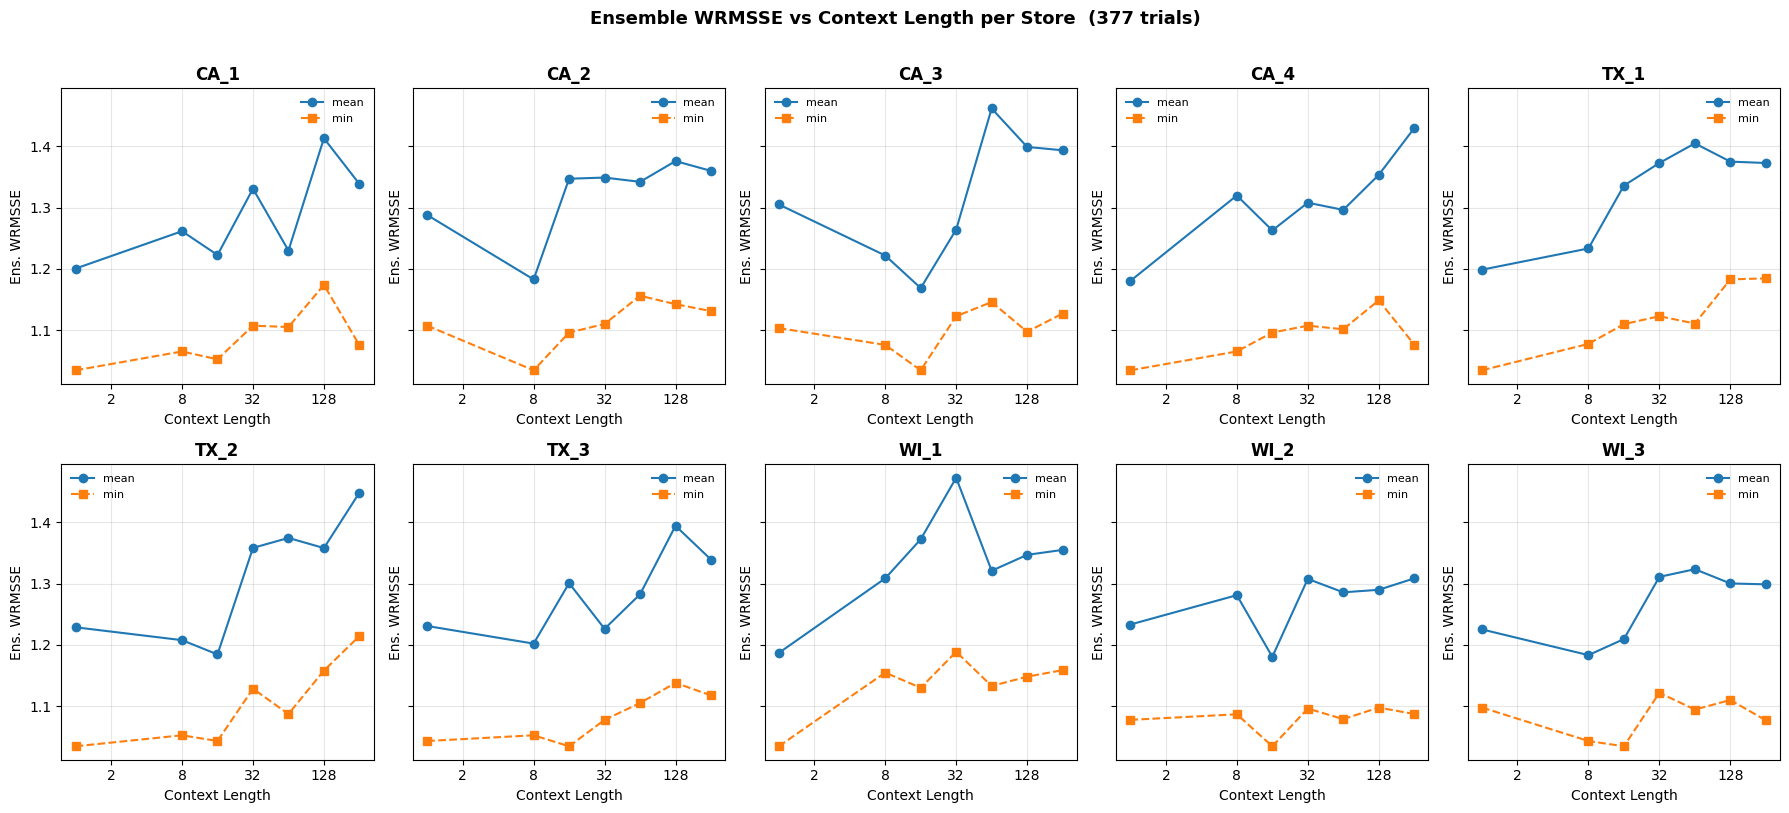

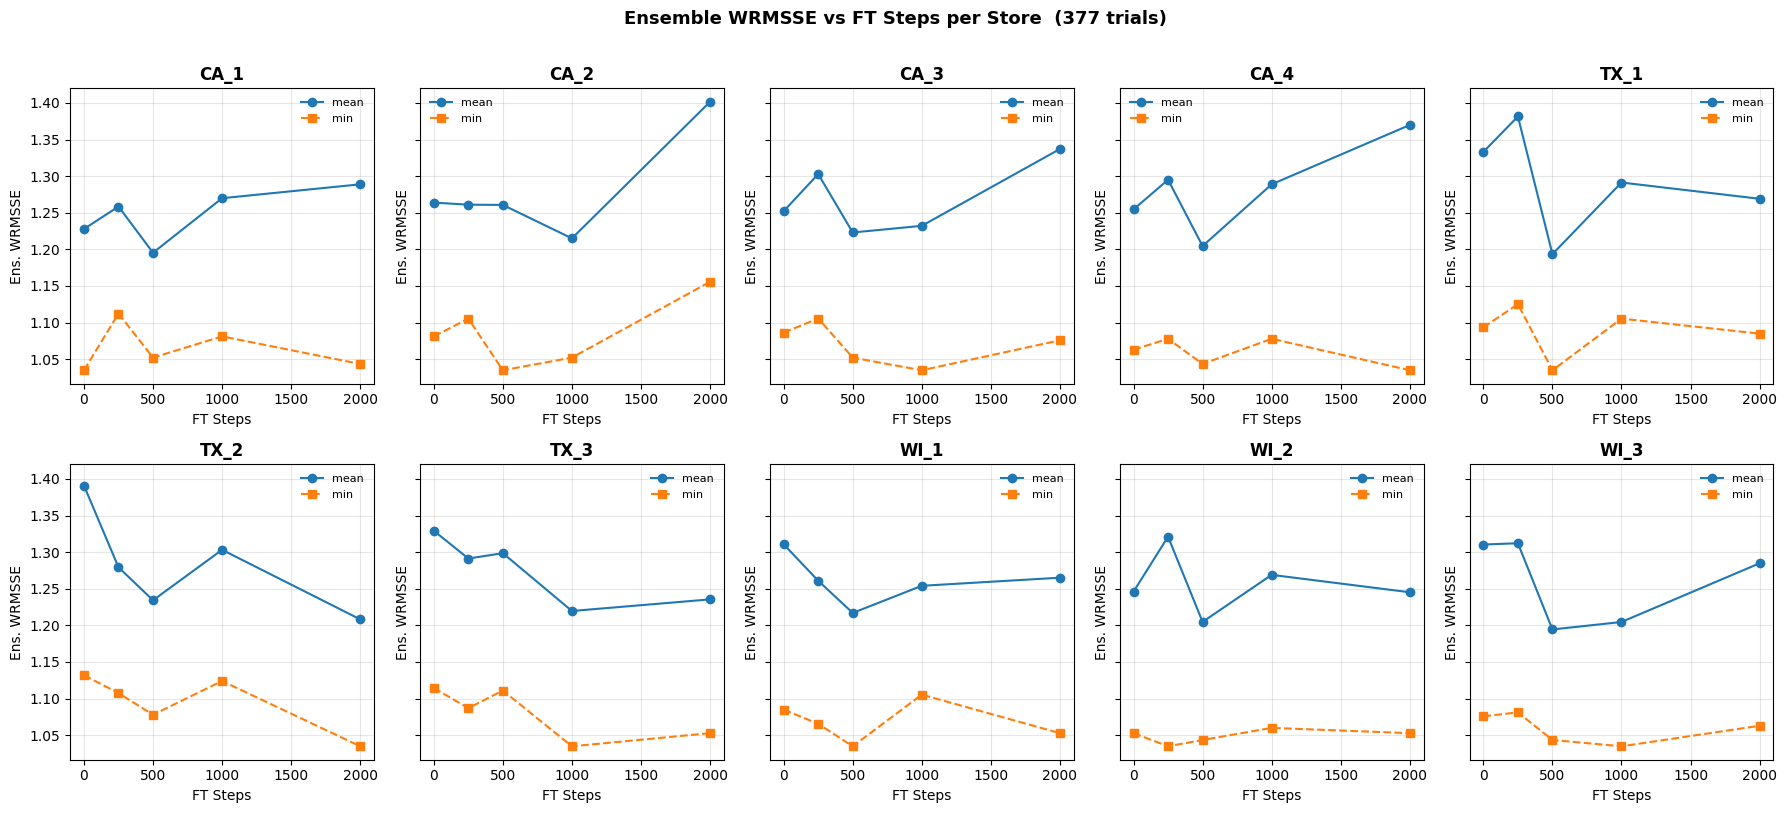

In [14]:
# ── CL vs WRMSSE — one subplot per store ────────────────────────────────────
if not df_trials.empty:
    ncols = 5
    nrows = (len(STORES) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, store in zip(axes, STORES):
        sk  = _store_key(store)
        col = f"params_CL_{sk}"
        if col not in df_trials.columns:
            ax.set_visible(False)
            continue
        grp = df_trials.groupby(col)["WRMSSE"].agg(["mean", "min"]).reset_index()
        ax.plot(grp[col], grp["mean"], marker="o", label="mean")
        ax.plot(grp[col], grp["min"],  marker="s", linestyle="--", label="min")
        ax.set_xscale("log", base=2)
        ax.set_title(store, fontweight="bold")
        ax.set_xlabel("Context Length")
        ax.set_ylabel("Ens. WRMSSE")
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.legend(frameon=False, fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(STORES):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Ensemble WRMSSE vs Context Length per Store  ({len(df_trials)} trials)",
        fontsize=13, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()

# ── ft_steps vs WRMSSE ───────────────────────────────────────────────────────
if not df_trials.empty:
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, store in zip(axes, STORES):
        sk  = _store_key(store)
        col = f"params_ft_steps_{sk}"
        if col not in df_trials.columns:
            ax.set_visible(False)
            continue
        grp = df_trials.groupby(col)["WRMSSE"].agg(["mean", "min"]).reset_index()
        ax.plot(grp[col], grp["mean"], marker="o", label="mean")
        ax.plot(grp[col], grp["min"],  marker="s", linestyle="--", label="min")
        ax.set_title(store, fontweight="bold")
        ax.set_xlabel("FT Steps")
        ax.set_ylabel("Ens. WRMSSE")
        ax.legend(frameon=False, fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(STORES):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Ensemble WRMSSE vs FT Steps per Store  ({len(df_trials)} trials)",
        fontsize=13, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()

In [15]:
# ── Generate best STORE_CONFIGS for store_ensemble_v1.ipynb ─────────────────
# Copy-paste the printed dict into the config cell of store_ensemble_v1.

if df_trials.empty:
    print("No trials completed — run HPO first.")
else:
    best_t = study.best_trial
    _param_map = {
        "context_length": "CL",
        "ft_steps":       "ft_steps",
        "ft_mode":        "ft_mode",
        "ft_lr":          "ft_lr",
        "ft_bs":          "ft_bs",
        "use_is_weekend": "use_is_weekend",
        "use_event":      "use_event",
        "use_price":      "use_price",
        "use_snap":       "use_snap",
    }

    best_store_configs: dict[str, dict] = {}
    for store in STORES:
        sk  = _store_key(store)
        cfg = {}
        for cfg_key, param_key in _param_map.items():
            col = f"params_{param_key}_{sk}"
            if col in df_trials.columns:
                cfg[cfg_key] = best_t.params.get(
                    f"{param_key}_{sk}",
                    df_trials.iloc[0].get(col),
                )
            else:
                cfg[cfg_key] = best_t.user_attrs.get(f"{param_key}_{sk}")
        best_store_configs[store] = cfg

    print(f"# Best trial #{best_t.number}  WRMSSE = {best_t.value:.4f}")
    print("STORE_CONFIGS = {")
    for store, cfg in best_store_configs.items():
        print(f'    "{store}": {{')
        for k, v in cfg.items():
            print(f'        "{k}": {repr(v)},')
        print("    },")
    print("}")

    # Also show as a summary DataFrame
    summary_df = pd.DataFrame(best_store_configs).T
    summary_df.index.name = "store"
    display(
        summary_df.style
        .set_caption(f"Best per-store config — trial #{best_t.number}  WRMSSE={best_t.value:.4f}")
    )

# Best trial #367  WRMSSE = 1.0348
STORE_CONFIGS = {
    "CA_1": {
        "context_length": 1,
        "ft_steps": 0,
        "ft_mode": 'lora',
        "ft_lr": 1e-06,
        "ft_bs": 32,
        "use_is_weekend": False,
        "use_event": True,
        "use_price": True,
        "use_snap": False,
    },
    "CA_2": {
        "context_length": 8,
        "ft_steps": 500,
        "ft_mode": 'lora',
        "ft_lr": 0.0001,
        "ft_bs": 32,
        "use_is_weekend": True,
        "use_event": False,
        "use_price": False,
        "use_snap": False,
    },
    "CA_3": {
        "context_length": 16,
        "ft_steps": 1000,
        "ft_mode": 'lora',
        "ft_lr": 0.0001,
        "ft_bs": 32,
        "use_is_weekend": True,
        "use_event": False,
        "use_price": False,
        "use_snap": False,
    },
    "CA_4": {
        "context_length": 1,
        "ft_steps": 2000,
        "ft_mode": 'lora',
        "ft_lr": 0.01,
        "ft_bs": 32,
        "use_is_week

,context_length,ft_steps,ft_mode,ft_lr,ft_bs,use_is_weekend,use_event,use_price,use_snap
store,,,,,,,,,
CA_1,1,0,lora,0.000001,32,False,True,True,False
CA_2,8,500,lora,0.000100,32,True,False,False,False
CA_3,16,1000,lora,0.000100,32,True,False,False,False
CA_4,1,2000,lora,0.010000,32,True,True,True,True
TX_1,1,500,lora,0.010000,32,True,False,False,False
TX_2,1,2000,lora,0.000010,32,False,False,True,False
TX_3,16,1000,lora,0.000100,32,True,False,False,False
WI_1,1,500,lora,0.000100,32,False,True,True,False
WI_2,16,250,full,0.000001,32,False,True,True,True


In [16]:
from pathlib import Path

out = Path(f"/mnt/lab/nmwamsojo/results/m5_hpo_store_ensemble_v1_{CUTOFF_DAY.replace('-', '')}.csv")
out.parent.mkdir(parents=True, exist_ok=True)
df_trials.to_csv(out, index=False)
print(f"Results saved \u2192 {out}  ({len(df_trials)} rows)")

Results saved → /mnt/lab/nmwamsojo/results/m5_hpo_store_ensemble_v1_20160424.csv  (377 rows)
